## GROUP N°

## NAMES 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import other libraries when needed 

## 1. DATA PROCESSING

In [2]:
# Load raw data
df = pd.read_parquet("dataDumper.parquet")

In [3]:
df.head()

,Time_utc,VehicleName,VehicleType,Pressure_Pa_1,Pressure_Pa_2,Pressure_Pa_3,Pressure_Pa_4,Pressure_Pa_5,Pressure_Pa_6,Temperature_K_1,...,Altitude_m,Speed_mps,epsilonX,epsilonY,epsilonZ,epsilonSpeed,AtmosphericPressure_Pa,dt_s,dd_m,RatioPayload
0,2023-01-01 00:00:00.328,C-132,Dumper,993010.933333,1.003995e+06,856000.0,798005.466667,819994.533333,864994.533333,346.15,...,4581.000000,9.003,6.207,6.312,23.000000,0.0,59002.557667,4.912,41.480140,0.0
1,2023-01-01 00:00:05.338,C-132,Dumper,993177.933329,1.003911e+06,856000.0,798088.966665,819911.033335,864911.033335,346.15,...,4577.600098,9.003,6.393,6.797,27.600000,0.0,59028.296172,5.010,45.952211,0.0
2,2023-01-01 00:00:10.331,C-132,Dumper,993344.366669,1.003828e+06,856000.0,798172.183334,819827.816666,864827.816666,346.15,...,4573.000000,9.723,6.721,7.631,32.200001,0.0,59064.789917,4.993,47.007842,0.0
3,2023-01-01 00:00:15.325,C-132,Dumper,993510.833331,1.003745e+06,856000.0,798255.416666,819744.583334,864744.583334,346.15,...,4568.600098,9.620,6.361,6.504,23.000000,0.0,59101.596928,4.994,48.700870,0.0
4,2023-01-01 00:00:20.448,C-132,Dumper,993681.600000,1.003659e+06,856000.0,798340.800000,819659.200000,864659.200000,346.15,...,4564.500000,11.318,6.361,7.144,23.000000,0.0,59139.354701,5.123,52.675397,0.0


In [4]:
df.columns

Index(['Time_utc', 'VehicleName', 'VehicleType', 'Pressure_Pa_1',
       'Pressure_Pa_2', 'Pressure_Pa_3', 'Pressure_Pa_4', 'Pressure_Pa_5',
       'Pressure_Pa_6', 'Temperature_K_1', 'Temperature_K_2',
       'Temperature_K_3', 'Temperature_K_4', 'Temperature_K_5',
       'Temperature_K_6', 'ColdPressure_Pa_1', 'ColdPressure_Pa_2',
       'ColdPressure_Pa_3', 'ColdPressure_Pa_4', 'ColdPressure_Pa_5',
       'ColdPressure_Pa_6', 'Latitude_dd', 'Longitude_dd', 'Altitude_m',
       'Speed_mps', 'epsilonX', 'epsilonY', 'epsilonZ', 'epsilonSpeed',
       'AtmosphericPressure_Pa', 'dt_s', 'dd_m', 'RatioPayload'],
      dtype='object')

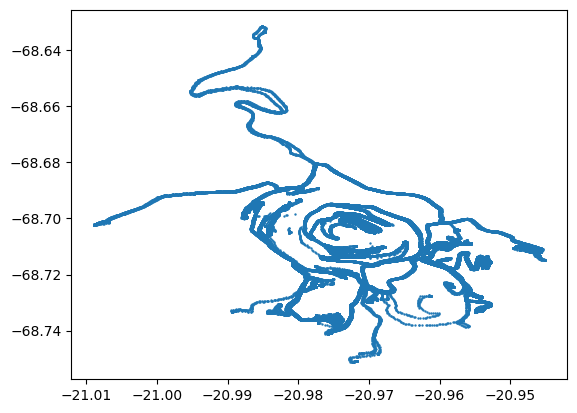

In [5]:
plt.scatter(x = df['Latitude_dd'], y = df['Longitude_dd'], s=0.5)

In [6]:
plot = df[['Longitude_dd','Latitude_dd']]

## Trajectory Construction

In [7]:
# Create Segments based on  RatioPayLoad
df[['phaseNb']] = df[['RatioPayload']].diff().abs().cumsum()

In [8]:
#Split the data into loaded trajectories and empty trajectories
segment_list = [data_phase for _, data_phase in df.groupby('phaseNb')]
empty_segment_list = []
load_segment_list = []

for segment in segment_list:
    if segment.RatioPayload.mean() == 0.0:
        empty_segment_list.append(segment)
    elif segment.RatioPayload.mean() == 1.0:
        load_segment_list.append(segment)

In [9]:
print(f'N° of Loaded segments :{len(load_segment_list)}')
print(f'N° of Empty segments :{len(empty_segment_list)}')

N° of Loaded segments :263
N° of Empty segments :263


<Axes: xlabel='Latitude_dd', ylabel='Longitude_dd'>

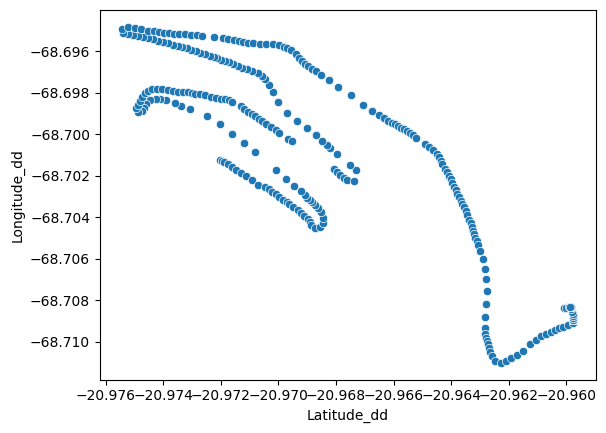

In [10]:
sns.scatterplot(x = load_segment_list[5]['Latitude_dd'],
                y = load_segment_list[5]['Longitude_dd'])

## 2. DATA ANALYSIS

Perform a comprehensive analysis of the dataset to uncover underlying patterns or characteristics. Visualize data distributions and relationships, such as speed vs. time, acceleration profiles, or geographical movements ... BE CURIOUS 

In [15]:
# ANALYSE THE MUTLIVARIATE TIME SERIES, TRY TO FIND PATTERNS AND CORRELATIONS INT THE DATA
# CHECK HOW THE DUMPER BEHAVES, SPEED, ACCELERATION, ... ETC

In [11]:
print(len(df))

201312


In [12]:
print(df.dtypes)
print(df.isna().sum())

Time_utc                   object
VehicleName                object
VehicleType                object
Pressure_Pa_1             float64
Pressure_Pa_2             float64
Pressure_Pa_3             float64
Pressure_Pa_4             float64
Pressure_Pa_5             float64
Pressure_Pa_6             float64
Temperature_K_1           float64
Temperature_K_2           float64
Temperature_K_3           float64
Temperature_K_4           float64
Temperature_K_5           float64
Temperature_K_6           float64
ColdPressure_Pa_1         float64
ColdPressure_Pa_2         float64
ColdPressure_Pa_3         float64
ColdPressure_Pa_4         float64
ColdPressure_Pa_5         float64
ColdPressure_Pa_6         float64
Latitude_dd               float64
Longitude_dd              float64
Altitude_m                float64
Speed_mps                 float64
epsilonX                  float64
epsilonY                  float64
epsilonZ                  float64
epsilonSpeed              float64
AtmosphericPre

In [13]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
print(missing_report.sort_values(by='missing_percent', ascending=False))

                        missing_count  missing_percent
Temperature_K_1                  3067         1.523506
Pressure_Pa_1                    3067         1.523506
ColdPressure_Pa_1                3067         1.523506
dd_m                             2634         1.308417
AtmosphericPressure_Pa            957         0.475381
ColdPressure_Pa_4                 224         0.111270
Temperature_K_4                   224         0.111270
Pressure_Pa_4                     224         0.111270
Temperature_K_2                   206         0.102329
ColdPressure_Pa_2                 206         0.102329
Pressure_Pa_2                     206         0.102329
Pressure_Pa_6                     154         0.076498
ColdPressure_Pa_6                 154         0.076498
Temperature_K_6                   154         0.076498
ColdPressure_Pa_5                 134         0.066563
Temperature_K_5                   134         0.066563
Pressure_Pa_5                     134         0.066563
ColdPressu

In [15]:
df['Time_utc'] = pd.to_datetime(df['Time_utc'], format='mixed')

df = df.sort_values('Time_utc')
df = df.set_index('Time_utc')


In [17]:
df = df.interpolate(method='time')

df.isna().sum()


C:\Users\elina\AppData\Local\Temp\ipykernel_24560\609065631.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time')


VehicleName               0
VehicleType               0
Pressure_Pa_1             0
Pressure_Pa_2             0
Pressure_Pa_3             0
Pressure_Pa_4             0
Pressure_Pa_5             0
Pressure_Pa_6             0
Temperature_K_1           0
Temperature_K_2           0
Temperature_K_3           0
Temperature_K_4           0
Temperature_K_5           0
Temperature_K_6           0
ColdPressure_Pa_1         0
ColdPressure_Pa_2         0
ColdPressure_Pa_3         0
ColdPressure_Pa_4         0
ColdPressure_Pa_5         0
ColdPressure_Pa_6         0
Latitude_dd               0
Longitude_dd              0
Altitude_m                0
Speed_mps                 0
epsilonX                  0
epsilonY                  0
epsilonZ                  0
epsilonSpeed              0
AtmosphericPressure_Pa    0
dt_s                      0
dd_m                      0
RatioPayload              0
phaseNb                   1
dtype: int64

Text(0.5, 1.0, 'All GPS points')

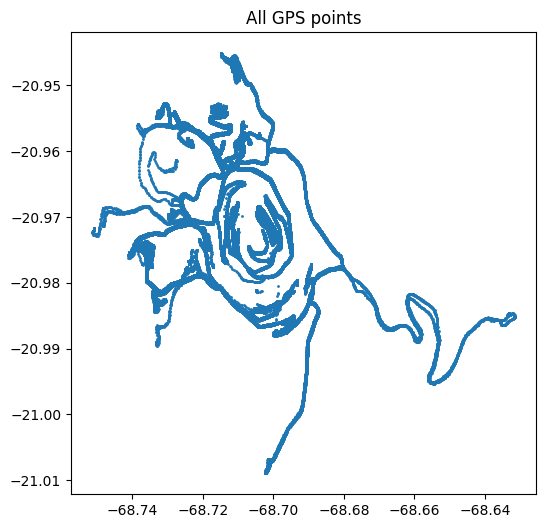

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(df['Longitude_dd'], df['Latitude_dd'], s=1)
plt.title("All GPS points")


Text(0.5, 1.0, 'GPS trajectory colored by speed')

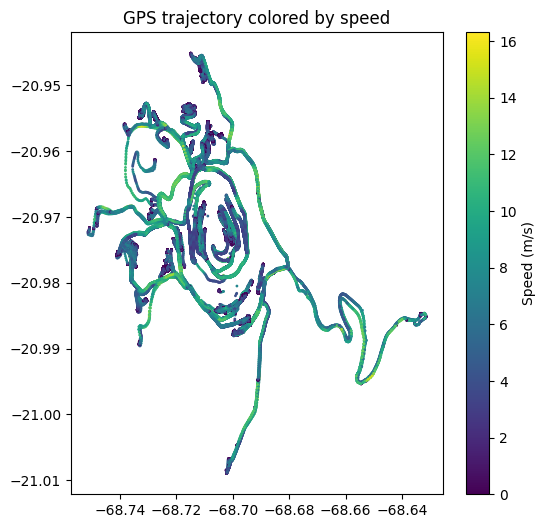

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(df['Longitude_dd'], df['Latitude_dd'], c=df['Speed_mps'], s=1)
plt.colorbar(label="Speed (m/s)")
plt.title("GPS trajectory colored by speed")


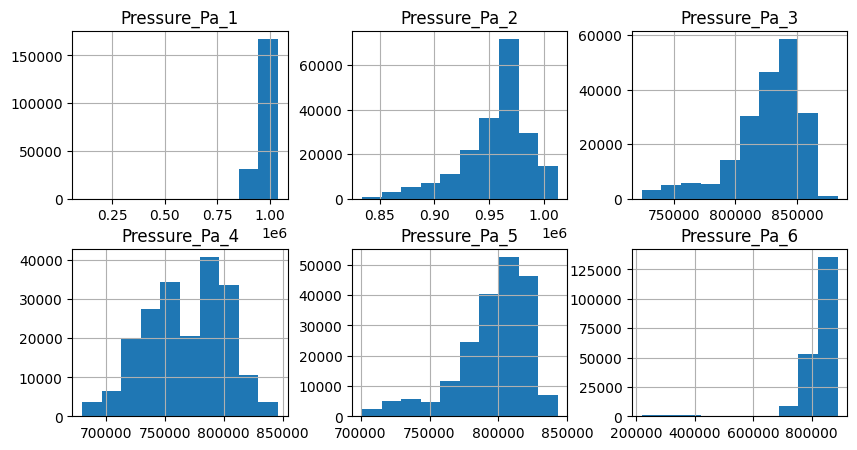

In [14]:
pressure_cols = [f'Pressure_Pa_{i}' for i in range(1,7)]

df[pressure_cols].hist(figsize=(10,5), layout=(2,3))
plt.show()

--- Pressure_Pa_1 ---
count    1.982450e+05
mean     9.732335e+05
std      4.255169e+04
min      1.080000e+05
25%      9.577784e+05
50%      9.850000e+05
75%      9.980271e+05
max      1.037933e+06
Name: Pressure_Pa_1, dtype: float64


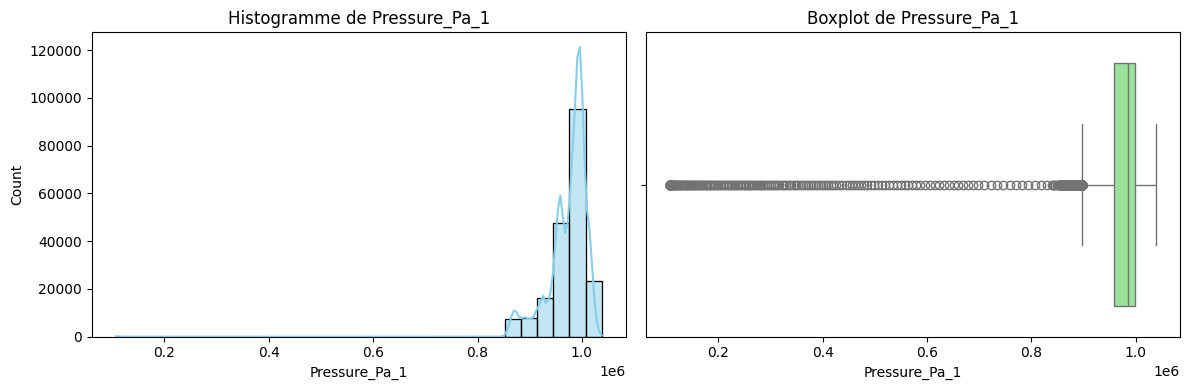

--- Pressure_Pa_2 ---
count    2.011060e+05
mean     9.565414e+05
std      3.100233e+04
min      8.340000e+05
25%      9.428281e+05
50%      9.631741e+05
75%      9.740000e+05
max      1.012603e+06
Name: Pressure_Pa_2, dtype: float64


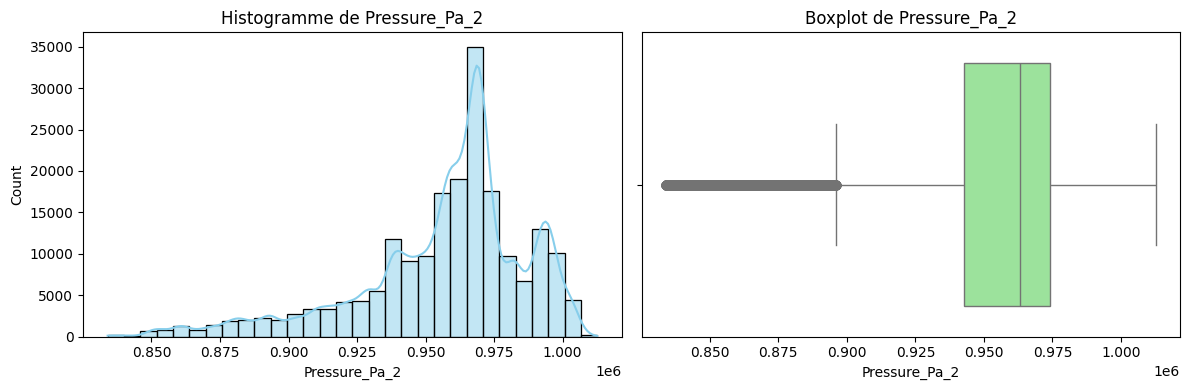

--- Pressure_Pa_3 ---
count    201190.000000
mean     825615.415508
std       28712.677030
min      724000.000000
25%      814146.925001
50%      831426.741666
75%      846051.674995
max      882986.633335
Name: Pressure_Pa_3, dtype: float64


KeyboardInterrupt: 

In [20]:

# Sélectionner les colonnes numériques
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Analyse univariée automatique
for col in numeric_cols:
    print(f"--- {col} ---")
    print(df[col].describe())  # statistiques de base

    # Créer une figure avec 2 plots côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogramme avec KDE
    sns.histplot(df[col], kde=True, bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Histogramme de {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

In [ ]:
for col in categorical_cols:
    print(f"----{col}----")
    print(df[col].value_counts())

    plt.figure()
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Répartition de {col}")
    plt.show()

----Time_utc----
Time_utc
2023-01-01 00:00:00.328    1
2023-01-01 00:00:05.338    1
2023-01-01 00:00:10.331    1
2023-01-01 00:00:15.325    1
2023-01-01 00:00:20.448    1
                          ..
2023-01-14 23:59:40        1
2023-01-14 23:59:45        1
2023-01-14 23:59:50        1
2023-01-14 23:59:55        1
2023-01-15 00:00:00        1
Name: count, Length: 201312, dtype: int64


KeyboardInterrupt: 

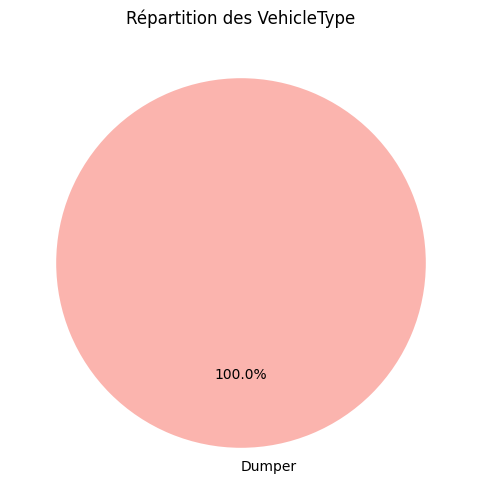

In [ ]:
# Compter les occurrences de chaque catégorie
counts = df['VehicleType'].value_counts()

# Tracer le camembert
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title("Répartition des VehicleType")
plt.show()


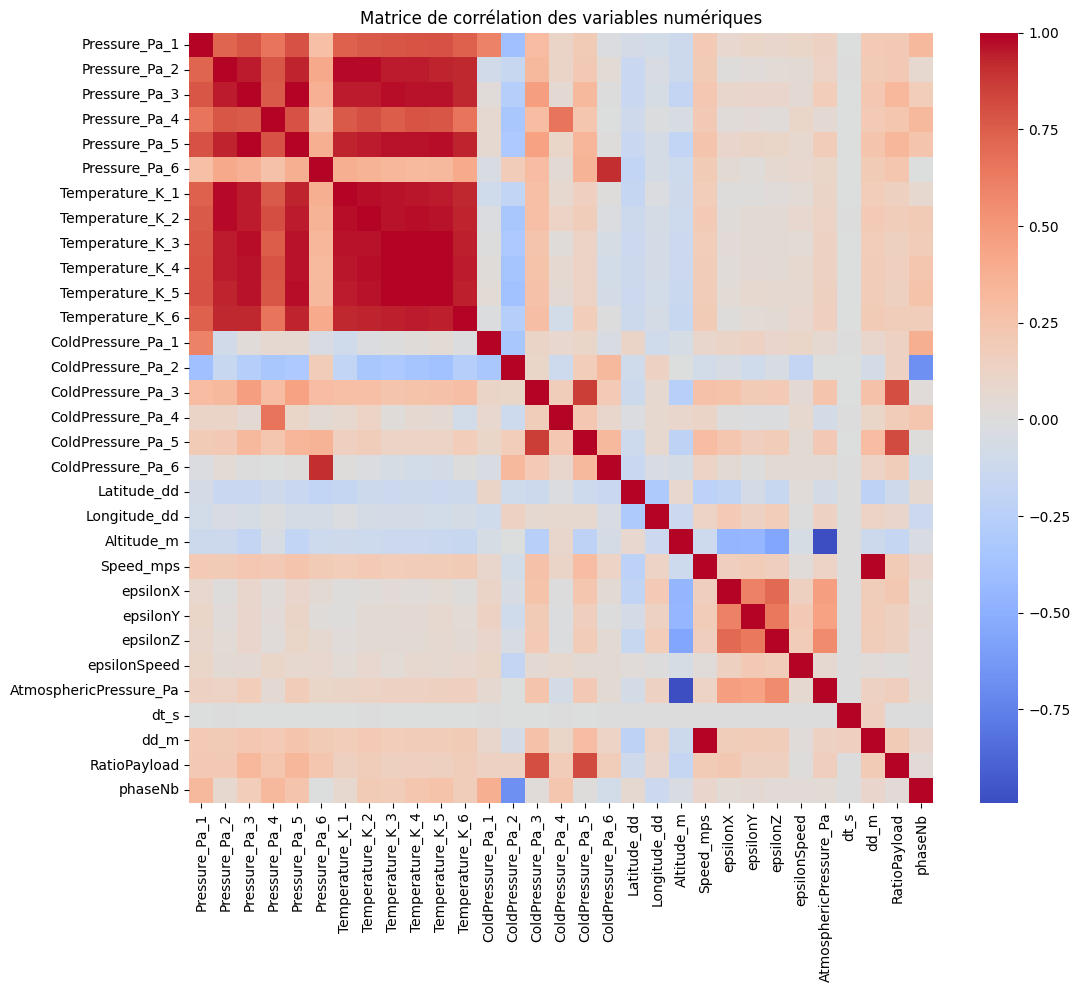

In [16]:
corr_matrix = df.corr(numeric_only=True)


# 3️⃣ Visualisation avec un heatmap (carte de chaleur)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


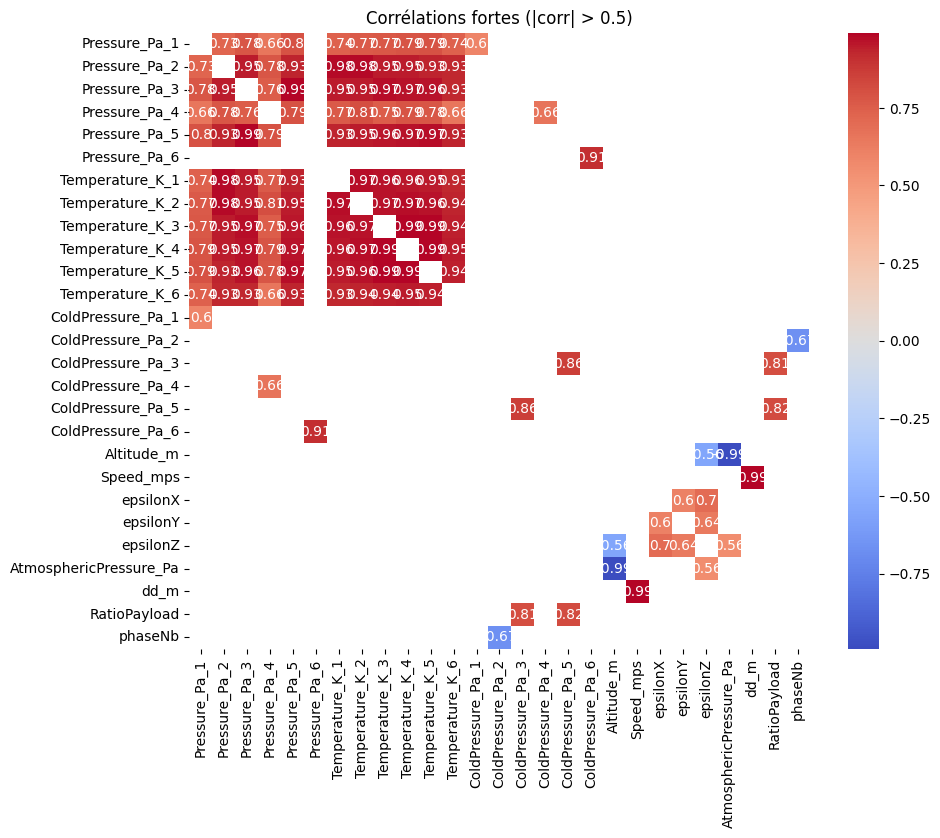

In [17]:

# On ne garde que les corrélations fortes (valeur absolue > 0.5)
strong_corr = corr_matrix[(corr_matrix.abs() > 0.5) & (corr_matrix.abs() != 1.0)]

# Supprimer les lignes/colonnes entièrement vides (NaN)
strong_corr = strong_corr.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Corrélations fortes (|corr| > 0.5)")
plt.show()

## 3. Distance Metrics for Trajectories 
Learn and apply suitable distance measures for trajectories. These may include Euclidean distance, Dynamic Time Warping (DTW), or Fréchet distance. Experiment with different metrics to find the most suitable one for clustering vehicle trajectories.
Trajectory Construction ( Based on the preprocessed data, construct trajectories that reflect the vehicle's movement over time. Define how you will represent a trajectory (e.g., as a series of time-stamped GPS coordinates or motion states).